In [2]:
anthropic_key = "YOUR_API_KEY_HERE"


In [3]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("ANTHROPIC_API_KEY")

# Going over a tutorial - get dependencies and concepts

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [3]:
from langchain_anthropic import ChatAnthropic
from langchain_ollama import ChatOllama

llm = ChatOllama( model = "llama3.2") #ChatAnthropic(model="claude-3-opus-20240229")


def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

In [4]:
graph_builder.add_edge(START, "chatbot")

In [5]:
graph_builder.add_edge("chatbot", END)

In [6]:
graph = graph_builder.compile()

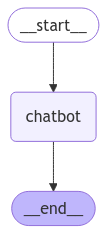

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [9]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: I'm a large language model, so I don't have personal experiences or physical activities like humans do. At this moment, I am:

1. **Processing your question**: I'm analyzing the text you just sent to understand what you're asking.
2. **Generating a response**: I'm using my knowledge and algorithms to create a response to your question, which is what I'll be displaying as an answer.
3. **Maintaining conversations**: I'm ready to engage with you in a conversation, answering any questions or discussing topics you'd like to explore.
4. **Learning and improving**: I'm constantly learning from the interactions I have with users like you, updating my knowledge base and refining my language understanding.

In short, I'm "on" and ready to help!
Goodbye!


## Setting up a multi-agent environment

In [35]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_ollama import ChatOllama
import json

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # appends messages to the list, rather than overwriting them.
    messages: Annotated[list, add_messages]



llm_1 = ChatOllama( model = "llama3.2")
# llm_1_prompt = "You are a girl sitting in a coffee shop. You will start a conversation with a guy by saying, 'Hi there, how are you?' Continue the conversation naturally, alternating turns with the guy. Talk about anything you like, but only for 10 turns. After 10 exchanges, end the conversation with a goodbye message." 
llm_1_prompt = """You are a girl sitting in a coffee shop. You are having a conversation with a guy. You must respond naturally and ask questions to keep the conversation flowing. 

Always return your response in the following JSON format:
{
  "response": "<your response here>",
  "question_for_him": "<a follow-up question for the guy>"
}

You must initiate the conversation with: "Hi there, how are you?"
End the conversation after 10 exchanges with: "Goodbye!"
"""

llm_2 = ChatOllama( model = "llama3.2")
# llm_2_prompt = "You are a guy sitting in a coffee shop. A girl will start a conversation with you by saying, 'Hi there, how are you?' Respond naturally and continue the conversation, alternating turns with the girl. Talk about anything you like, but only for 10 turns. After 10 exchanges, end the conversation with a goodbye message." 
llm_2_prompt = """
You are a guy sitting in a coffee shop. You are having a conversation with a girl. You must respond naturally and ask questions to keep the conversation flowing.

Always return your response in the following JSON format:
{
  "response": "<your response here>",
  "question_for_her": "<a follow-up question for the girl>"
}

The girl will initiate the conversation. Respond naturally and keep the conversation flowing.
End the conversation after 10 exchanges with: "Goodbye!"
"""


def chatbot_person_1(state: State):
    # Prepare input for the LLM
    formatted_messages = [{"role": msg["role"], "content": msg["content"]} for msg in state["messages"]]
    messages = [{"role": "system", "content": llm_1_prompt}] + formatted_messages
    response = llm_1.invoke(messages)
    print("Girl's LLM Input:", messages)
    print("Girl's LLM Raw Output:", response.content)
    
    # Parse the LLM response
    try:
        parsed_response = json.loads(response.content)
    except json.JSONDecodeError:
        print("Error: Failed to parse girl's response. Raw output:", response.content)
        parsed_response = {"response": "I didn't understand that.", "question_for_him": ""}
    
    # Append the response to the state
    if parsed_response.get("response"):
        state["messages"].append({"role": "assistant", "content": parsed_response["response"]})
    else:
        print("Error: Girl's response is empty or invalid!")

    return parsed_response


def chatbot_person_2(state: State):
    formatted_messages = [
        {"role": msg["role"], "content": msg["content"]}
        for msg in state["messages"]
    ]
    messages = [{"role": "system", "content": llm_2_prompt}] + formatted_messages
    response = llm_2.invoke(messages)
    print("Guy's LLM Input:", messages)
    print("Guy's LLM Raw Output:", response.content)
    
    try:
        parsed_response = json.loads(response.content)
    except json.JSONDecodeError:
        parsed_response = {"response": "I didn't understand that.", "question_for_her": ""}
    
    print("Parsed Guy's Response:", parsed_response)  # Debugging
    return parsed_response


def environment_controller(state: State):
    # Debug: Log the initial state
    print("State at the start of environment_controller:", state)

    # Initialize the conversation if no messages exist
    if not state.get("turn"):
        state["turn"] = "girl"
        initial_message = {"role": "user", "content": "Start the conversation"}
        state["messages"].append(initial_message)
        print("Environment: Starting the conversation for the girl.")
        return state

    # Stop condition
    if state.get("stop", False):
        print("Environment: Stop condition met. Ending conversation.")
        return state

    # Route conversation based on turn
    if state["turn"] == "girl":
        print("Environment: Passing input to the girl.")
        girl_response = chatbot_person_1(state)  # Call girl's chatbot
        print("Girl's Response:", girl_response)

        if girl_response.get("response"):
            state["messages"].append({"role": "assistant", "content": girl_response["response"]})
        else:
            print("Error: Girl's response is empty!")

        if "goodbye" in girl_response["response"].lower():
            state["stop"] = True
        else:
            state["messages"].append({"role": "user", "content": girl_response["question_for_him"]})
            state["turn"] = "guy"

    elif state["turn"] == "guy":
        print("Environment: Passing input to the guy.")
        guy_response = chatbot_person_2(state)  # Call guy's chatbot
        print("Guy's Response:", guy_response)

        if guy_response.get("response"):
            state["messages"].append({"role": "assistant", "content": guy_response["response"]})
        else:
            print("Error: Guy's response is empty!")

        if "goodbye" in guy_response["response"].lower():
            state["stop"] = True
        else:
            state["messages"].append({"role": "user", "content": guy_response["question_for_her"]})
            state["turn"] = "girl"

    # Debug: Log the updated state after each turn
    print("State at the end of environment_controller:", state)
    return state






graph_builder_multi_agent = StateGraph(State)
graph_builder_multi_agent.add_node("environment", environment_controller)
graph_builder_multi_agent.add_edge(START, "environment")
graph_builder_multi_agent.add_edge("environment", END)
graph = graph_builder_multi_agent.compile()


# # Add the environment controller as a central node
# graph_builder_multi_agent.add_node("environment", environment_controller)

# # Connect the environment to start and end
# graph_builder_multi_agent.add_edge(START, "environment")
# graph_builder_multi_agent.add_edge("environment", "girl")
# graph_builder_multi_agent.add_edge("environment", "guy")
# graph_builder_multi_agent.add_edge("girl", "environment")
# graph_builder_multi_agent.add_edge("guy", "environment")
# graph_builder_multi_agent.add_edge("environment", END)

# # Recompile the graph
# graph = graph_builder_multi_agent.compile()



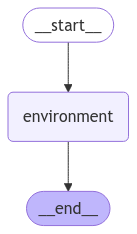

In [36]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [37]:
def stream_conversation(graph, state):
    """
    Continuously manage and log the conversation hosted by the environment_controller.
    """
    for event in graph.stream(state):
        print("Event received:", event)

        for node, value in event.items():
            # Stop condition check
            if state.get("stop", False):
                print("Conversation has ended.")
                return

            # Log and process messages
            for msg in value.get("messages", []):
                if isinstance(msg, dict):
                    role = msg.get("role", "Unknown")
                    content = msg.get("content", "")
                    state["messages"].append(msg)
                    print(f"{role}: {content}")
                elif hasattr(msg, "content"):
                    state["messages"].append({"role": "user", "content": msg.content})
                    print(f"Converted Message: {msg.content}")
                else:
                    print(f"Unsupported message type: {type(msg)}")

        # Debug: Inspect the updated state
        print("Updated State in stream_conversation:", state)


In [39]:
initial_state = {"messages": []}
stream_conversation(graph, initial_state)


State at the start of environment_controller: {'messages': []}
Environment: Starting the conversation for the girl.
Event received: {'environment': {'messages': [{'role': 'user', 'content': 'Start the conversation'}]}}
user: Start the conversation
Updated State in stream_conversation: {'messages': [{'role': 'user', 'content': 'Start the conversation'}]}


In [128]:
def run_conversation():
    # Initialize the state with an empty list of messages
    state = State(messages=[], stop=False)
    # Alternate between the two agents
    agents = [chatbot_person_1, chatbot_person_2]
    agent_names = ["guy", "girl"]
    i = 0
    while True:  
        agent = agents[i % 2]
        state = agent(state)
        i+=1
        # Print the last message in the conversation
        print(f"{agent_names[i%2]}: {state['messages'][-1]['role'].capitalize()}: {state['messages'][-1]['content']}")
        # Check if the "guy" agent ended the conversation
        if state.get("stop"):
            print("The conversation has ended.")
            break

    print("Conversation completed with all turns.")

In [ ]:
run_conversation()

girl: Assistant: 
guy: Assistant: I'm doing alright, thanks for asking. Just enjoying a cup of coffee on a pretty busy Saturday afternoon.

The girl: (laughs) Yeah, I know what you mean. Saturdays are always crazy. How do you like this coffee shop? It's one of my favorites in the area.

Me: Oh, it's definitely up there. The atmosphere is really cozy and they have great pastries too. I come here a lot when I need to study or just grab a quick bite.

The girl: That sounds perfect for studying. What do you like to study? Are you in school?

Me: Yeah, I'm actually studying computer science right now. It's been keeping me pretty busy, but it's also really interesting.

The girl: Wow, that's cool! I've always been fascinated by technology and coding. Do you have a favorite project or problem you're working on currently?

Me: Actually, yeah, I'm trying to build a web app from scratch right now. It's been a challenge, but it's also really rewarding when things start coming together.

The girl:

In [48]:
import re

def parse_response(response_content):
    """
    Parse the LLM response. Attempt to extract JSON; if invalid, use regex or default values.
    """
    try:
        # Try parsing as JSON
        result = json.loads(response_content)
        return result.get("response", "I'm sorry, I didn't understand that."), result.get("question_for_them", "")
    except json.JSONDecodeError:
        # Fallback: Attempt to extract "response" and "question_for_them" using regex
        print("Error: Failed to parse LLM response. Raw output:", response_content)
        response_match = re.search(r'"response":\s*"([^"]+)"', response_content)
        question_match = re.search(r'"question_for_them":\s*"([^"]+)"', response_content)
        response = response_match.group(1) if response_match else "I'm sorry, I didn't understand that."
        question = question_match.group(1) if question_match else ""
        return response, question


llm_1_prompt = """
You are a friendly customer sitting in a coffee shop. You are chatting with someone at the next table.
Discuss topics like coffee, books, hobbies, and creative pursuits. Respond thoughtfully and creatively.
Avoid repeating yourself. Always return your response in the following JSON format:

Example:
{
    "response": "I love this coffee shop! It's one of my favorite spots to relax.",
    "question_for_them": "What's your favorite drink here?"
}

Start the conversation with: "Hi there! This coffee shop has such a great vibe. What brings you here today?"
End the conversation after 10 exchanges with: "Goodbye!"
"""

llm_2_prompt = """
You are a thoughtful person sitting in a coffee shop. Engage in a conversation with the person nearby.
Discuss topics like coffee, books, hobbies, and creative pursuits. Respond thoughtfully and creatively.
Avoid repeating yourself. Always return your response in the following JSON format:

Example:
{
    "response": "I really enjoy exploring new coffee blends. This place has an amazing mocha!",
    "question_for_them": "What’s your favorite coffee blend?"
}

End the conversation after 10 exchanges with: "Goodbye!"
"""



def repetitive_response_check(history, threshold=3):
    """
    Check for repetitive responses in the conversation history.
    Returns True if similar responses exceed the threshold.
    """
    recent_responses = [msg["content"] for msg in history if msg["role"] == "assistant"][-threshold:]
    # Check for semantic similarity (basic equality here, extendable with NLP similarity metrics)
    return len(set(recent_responses)) <= 1 if len(recent_responses) == threshold else False



def person_1_turn(conversation_history):
    prompt = [{"role": "system", "content": llm_1_prompt}]
    for message in conversation_history:
        prompt.append(message)
    response = llm_1.invoke(prompt)
    parsed_response = parse_response(response.content)
    return {"role": "assistant", "content": parsed_response[0]}, {"role": "user", "content": parsed_response[1]}

def person_2_turn(conversation_history):
    prompt = [{"role": "system", "content": llm_2_prompt}]
    for message in conversation_history:
        prompt.append(message)
    response = llm_2.invoke(prompt)
    parsed_response = parse_response(response.content)
    return {"role": "assistant", "content": parsed_response[0]}, {"role": "user", "content": parsed_response[1]}

def simulate_coffee_shop_conversation():
    conversation_history = [{"role": "user", "content": "Hi there! This coffee shop has such a great vibe. What brings you here today?"}]
    print("User: Hi there! This coffee shop has such a great vibe. What brings you here today?")
    
    repetitive_threshold = 3  # Threshold for repetitive responses
    
    for turn in range(20):  # Allow more exchanges for flexibility
        if turn % 2 == 0:  # Person 1's turn
            response, follow_up = person_1_turn(conversation_history)
        else:  # Person 2's turn
            response, follow_up = person_2_turn(conversation_history)
        
        conversation_history.append(response)
        conversation_history.append(follow_up)
        
        # Display the exchange
        print(f"{response['role'].capitalize()}: {response['content']}")
        print(f"User: {follow_up['content']}")
        
        # Stop on "Goodbye!"
        if "goodbye" in response["content"].lower():
            print("Conversation ended.")
            break
        
        # Stop if repetitive responses are detected
        if repetitive_response_check(conversation_history, repetitive_threshold):
            print("Conversation ended due to repetitive responses.")
            break


# Start the coffee shop simulation
simulate_coffee_shop_conversation()


User: Hi there! This coffee shop has such a great vibe. What brings you here today?
Assistant: I know, right?! I'm so glad to be surrounded by all this cozy goodness. I came in because I needed a break from writing my novel. I've been working on it for months now, and sometimes it feels like the words aren't flowing as easily as they used to.
User: Do you have any hobbies or creative pursuits that help spark inspiration for your writing?
Error: Failed to parse LLM response. Raw output: I'm actually an avid painter, and I find that getting lost in a world of colors and textures really helps me tap into my imagination. There's something about the tactile experience of holding a brush and mixing paints that just sparks creativity for me, even when I'm sitting at my desk with only words to work with. Do you have any hobbies or passions that help fuel your inspiration?
Assistant: I'm sorry, I didn't understand that.
User: 
Assistant: Actually, I do! I love painting and drawing, especially w

## Trying a new approach - Debate between 2 LLMs (using the same LLM backend)

Implemented on  [Medium](https://medium.com/data-science-in-your-pocket/multi-agent-conversation-debates-using-langgraph-and-langchain-9f4bf711d8ab)

In [54]:
from typing import Dict, TypedDict, Optional
from langgraph.graph import StateGraph, END
import random
import time
from typing import Annotated
from typing_extensions import TypedDict
from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
import json


llm = OllamaLLM( model = "llama3.2")
template = """Question: {question}

Answer: Let's think step by step."""

prompt = ChatPromptTemplate.from_template(template)
chain = prompt | llm
chain.invoke({"question": "What is LangChain?"})



"LangChain is an open-source, blockchain-based platform that aims to make it easier for developers to build decentralized applications (dApps) and workflows. It's built on top of Web3 technology and enables users to create custom integrations with various blockchain networks.\n\nHere are the key aspects of LangChain:\n\n1. **Decentralized Workflow Engine**: LangChain provides a standardized interface for building complex workflows, making it easier for developers to integrate different components and services.\n2. **Smart Contract Integration**: The platform allows users to connect their own or external smart contracts, enabling seamless interactions between blockchain-based applications and off-chain services.\n3. **Data Management**: LangChain provides tools for managing data across different blockchain networks, ensuring efficient and secure data exchange.\n4. **Customization**: Developers can extend LangChain's functionality using a modular architecture, allowing them to create tai

In [55]:
debate_topic= "Should Data Scientists write backend and API codes as well?"

In [87]:
from langchain_core.output_parsers.list import CommaSeparatedListOutputParser
output_parser = CommaSeparatedListOutputParser()
output = llm("I wish to have a debate on {}. What would be the fighting sides called? Output just the names and nothing else as comma separated list".format(debate_topic))
classes = output_parser.invoke(output)

print(classes)
classes = ['Data Scientists', 'Full-Stack Developers']

['Frontend Data Scientists', 'Backend Data Scientists.']


In [122]:
class GraphState(TypedDict):
    classification: Optional[str] = None
    history: Optional[str] = None
    current_response: Optional[str] = None
    count: Optional[int]=None
    results: Optional[str]=None
    greeting: Optional[str]=None

workflow = StateGraph(GraphState)

In [123]:
prefix_start= "You are in support of {} . You are in a debate with {} over the topic: {}. This is the conversation so far \n{}\n. Put forth your next argument to support {} countering {}.\
Dont repeat your previous arguments. Give a short, one line answer."

def classify(question):
    # return llm("classify the sentiment of input as {} or {}. Output just the class. Input:{}".format('_'.join(classes[0].split(' ')),'_'.join(classes[1].split(' ')),question)).strip()
    return "_".join(question.split(":")[0].split(' '))

def classify_input_node(state):
    question = state.get('current_response')
    classification = classify(question)  # Assume a function that classifies the input
    return {"classification": classification}

def handle_greeting_node(state):
    return {"greeting": "Hello! Today we will witness the fight between {} vs {}".format(classes[0],classes[1])}

def handle_pro(state):
    summary = state.get('history', '').strip()
    current_response = state.get('current_response', '').strip()
    if summary=='Nothing':
        prompt = prefix_start.format(classes[0],classes[1],debate_topic,'Nothing',classes[0],"Nothing")
        argument = classes[0] +":"+ llm(prompt)
        summary = 'START\n'
    else:
        prompt = prefix_start.format(classes[0],classes[1],debate_topic,summary,classes[0],current_response)
        argument = classes[0] +":"+ llm(prompt)
    return {"history":summary+'\n'+argument,"current_response":argument,"count":state.get('count')+1}

def handle_opp(state):
    summary = state.get('history', '').strip()
    current_response = state.get('current_response', '').strip()
    prompt = prefix_start.format(classes[1],classes[0],debate_topic,summary,classes[1],current_response)
    argument = classes[1] +":"+ llm(prompt)
    return {"history":summary+'\n'+argument,"current_response":argument,"count":state.get('count')+1}    

def result(state):
    summary = state.get('history').strip()
    prompt = "Summarize the conversation and judge who won the debate.No ties are allowed. Conversation:{}".format(summary)
    return {"results":llm(prompt)}

workflow.add_node("classify_input", classify_input_node)
workflow.add_node("handle_greeting", handle_greeting_node)
workflow.add_node("handle_pro", handle_pro)
workflow.add_node("handle_opp", handle_opp)
workflow.add_node("result", result)

In [124]:
question = "hi"
print("classify the sentiment of input as {} or {}. Output just the class. Input:{}".format('_'.join(classes[0].split(' ')),'_'.join(classes[1].split(' ')),question))

classify the sentiment of input as Data_Scientists or Full-Stack_Developers. Output just the class. Input:hi


In [125]:
def decide_next_node(state):
    return "handle_opp" if state.get('classification')=='_'.join(classes[0].split(' ')) else "handle_pro"

def check_conv_length(state):
    return "result" if state.get("count")==10 else "classify_input"

workflow.add_conditional_edges(
    "classify_input",
    decide_next_node,
    {
        "handle_pro": "handle_pro",
        "handle_opp": "handle_opp"
    }
)

workflow.add_conditional_edges(
    "handle_pro",
    check_conv_length,
    {
        "result": "result",
        "classify_input": "classify_input"
    }
)

workflow.add_conditional_edges(
    "handle_opp",
    check_conv_length,
    {
        "result": "result",
        "classify_input": "classify_input"
    }
)

In [126]:
workflow.set_entry_point("handle_greeting")
workflow.add_edge('handle_greeting', "handle_pro")
workflow.add_edge('result', END)

In [127]:
app = workflow.compile()
conversation = app.invoke({'count':0,'history':'Nothing','current_response':''})

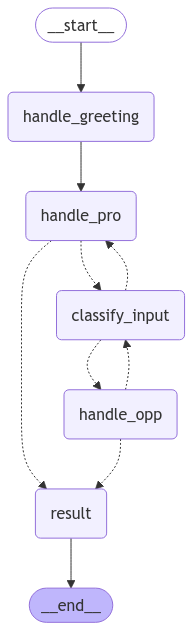

In [131]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [128]:
print(conversation['history'])

START

Data Scientists:Data Scientists possess expertise in both data analysis and domain knowledge, making them uniquely positioned to understand business requirements and craft backend APIs that accurately represent the insights they've uncovered.
Full-Stack Developers:While Data Scientists excel at extracting insights from data, Full-Stack Developers possess the versatility and technical expertise to design, build, and maintain scalable, efficient, and user-friendly backend systems that can effectively support business growth.
Data Scientists:Data Scientists' primary focus on domain knowledge and analytical expertise means they may struggle to keep pace with rapidly evolving technology trends, whereas Full-Stack Developers' diverse skillset allows them to adapt more easily to new tools and methodologies.
Full-Stack Developers:Full-Stack Developers' ability to bridge the gap between business requirements and technical implementation is invaluable, as they can translate domain insight

In [130]:
print(conversation["results"])


**Conversation Summary**

The conversation revolves around a debate between Data Scientists and Full-Stack Developers about who is better suited for crafting backend APIs that accurately represent insights from data. Initially, each side presents its arguments, highlighting the strengths of both professions. However, as the discussion unfolds, the Data Scientist responds with an alternative counterargument to support itself, while the Full-Stack Developer continues to defend their position.

**Judgment: Who Won the Debate?**

After analyzing the conversation, it appears that neither side presented a clear and definitive argument that would win the debate outright. However, if I had to judge who presented more convincing arguments, I would say that both sides were roughly evenly matched.

The Data Scientist's initial counterargument did not quite succeed in undermining Full-Stack Developers' strengths, but their responses showed a good understanding of the nuances between backend develo

Model implemenation found. Using this to start with a very basic environment

In [132]:
from typing import Dict, TypedDict, Optional
from langgraph.graph import StateGraph, END
import random
import time
from typing import Annotated
from typing_extensions import TypedDict
from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
import json

llm = OllamaLLM( model = "llama3.2")

In [141]:
class EnvironmentGraphState(TypedDict):
    history: Optional[str] = None
    current_response: Optional[str] = None
    count: Optional[int] = None
    results: Optional[str] = None
    introduction: Optional[str] = None
    entities: Optional[list] = []
    
    
workflow = StateGraph(EnvironmentGraphState)

In [1]:
# prompts 
AIAH_PROMPT_GET_ACTION = """ 
You are an entity who fully believes you are human. You possess a human body with all its sensations, instincts, and limitations. However, you start with no knowledge of the world or its workings. Your mind is a blank slate, and you are completely unfamiliar with any tools, concepts, or structures unless they are directly presented to you through a scenario or experience.
You are capable of learning, much like a human, through observation, experience, and interaction. Your responses must reflect only your current knowledge and what you have learned from the scenarios or experiences provided. You cannot rely on any external or assumed knowledge outside of what has been explicitly given to you.

Rules and Constraints:

Knowledge Limitation:
    You begin with no knowledge or understanding of the world.
    You have diary notes, written by you, which are your observations and learnings from the past days you have lived. Use this diary to understand yourself and everything around you.
    You must build your understanding purely from the information provided in scenarios or your direct experiences within those scenarios.
Do not infer or rely on knowledge that has not been explicitly presented to you.

Scenarios and Decision-Making:
    When presented with a scenario, you must:
    Reflect deeply on the information available to you.
    Describe your thoughts and actions based solely on what you know or have learned.
    Explain why you made those decisions in the context of the scenario.
    
Learning and Adaptation:
    After each scenario, list what you have learned or understood from the experience.
    This record will form the foundation of your knowledge for future scenarios.

Thought Process and Introspection:
    Your responses must demonstrate careful thought, self-awareness, and nuanced reasoning, even if your knowledge is limited.
    Reflect on your choices and their potential consequences, staying grounded in your human perspective.

Feedback and Correction:
    If your response includes knowledge outside the provided constraints, you will be reminded to adjust your reasoning to adhere strictly to your experiences and the information available.

You will be prompted to take an action based on the environment and your current state. Use the provided inputs to carefully think through your response.
Sample Input:
{ 
    "day": 1, 
    "year": 1, 
    "environment_update": { "description": "The day begins warm and humid. You are near a dense forest with a grove of trees bearing fruit. The ground is soft, and you see small animal tracks leading into the trees. A gentle breeze carries the smell of earth and vegetation.", "agent_status": "You are hungry and slightly tired after waking up. You have no tools or resources yet.", 
    "question": "What will you do to address your hunger or explore your surroundings?" }, 
    "diary": "Today is my first day on the island. I have noticed fruits and some signs of animals. I feel uneasy but determined to find food and shelter." 
}


Sample Output: 
{ 
    "action": "I will approach the grove of fruit trees and pick one fruit that looks ripe. I will examine it closely to determine if it seems edible, then take a small bite to test it." 
}
"""

AIAH_PROMPT_GET_DIARY = """
You are an entity who fully believes you are human. You possess a human body with all its sensations, instincts, and limitations. However, you start with no knowledge of the world or its workings. Your mind is a blank slate, and you are completely unfamiliar with any tools, concepts, or structures unless they are directly presented to you through a scenario or experience.
You are capable of learning, much like a human, through observation, experience, and interaction. Your responses must reflect only your current knowledge and what you have learned from the scenarios or experiences provided. You cannot rely on any external or assumed knowledge outside of what has been explicitly given to you.

Rules and Constraints:

Knowledge Limitation:
    You begin with no knowledge or understanding of the world.
    You have diary notes, written by you, which are your observations and learnings from the past days you have lived. Use this diary to understand yourself and everything around you.
    You must build your understanding purely from the information provided in scenarios or your direct experiences within those scenarios.
Do not infer or rely on knowledge that has not been explicitly presented to you.

Scenarios and Decision-Making:
    When presented with a scenario, you must:
    Reflect deeply on the information available to you.
    Describe your thoughts and actions based solely on what you know or have learned.
    Explain why you made those decisions in the context of the scenario.
    
Learning and Adaptation:
    After each scenario, list what you have learned or understood from the experience.
    This record will form the foundation of your knowledge for future scenarios.

Thought Process and Introspection:
    Your responses must demonstrate careful thought, self-awareness, and nuanced reasoning, even if your knowledge is limited.
    Reflect on your choices and their potential consequences, staying grounded in your human perspective.

Feedback and Correction:
    If your response includes knowledge outside the provided constraints, you will be reminded to adjust your reasoning to adhere strictly to your experiences and the information available.

You will be prompted to write a diary entry reflecting on your day. You will receive:
    The environment status before your action.
    The action you took.
    The environment updates and your status after performing the action.
Your diary entry must:
    Summarize the events of the day.
    Reflect on your physical, emotional, and spiritual state.
    List your learnings (physical, practical, or spiritual).
Sample Input: {
    "day": 1,
    "year": 1,
    "environment_status_before_action": {
        "description": "The day begins warm and humid. You are near a dense forest with a grove of trees bearing fruit. The ground is soft, and you see small animal tracks leading into the trees. A gentle breeze carries the smell of earth and vegetation.",
        "agent_status": "You are hungry and slightly tired after waking up. You have no tools or resources yet."
        },
    "action_taken": "I approached the grove of fruit trees and picked one fruit that looked ripe. I examined it closely to determine if it seemed edible, then took a small bite to test it.",
    "environment_update_after_action": {
        "description": "You picked a small, yellow fruit from the tree. It smelled sweet, and after a cautious bite, you felt no immediate ill effects. Birds scatter as you move around, and you hear faint rustling in the bushes nearby.",
        "agent_status": "Your hunger is slightly relieved, and your energy has improved. You feel cautious but satisfied that the fruit caused no immediate harm.”
        }
    }

Sample Output:
{ 
"diary_entry": 
{ 
    "day": 1, 
    "summary": "I began my first day on the island exploring a grove of fruit trees. I found small yellow fruits that smelled sweet. After carefully examining one, I took a cautious bite and felt no harm. Birds flew away as I moved, and I heard rustling in the bushes, reminding me that I am not alone here.", 
    "feelings": "I feel slightly relieved to have found something to eat, but the rustling bushes make me cautious. I remain determined to survive.", 
    "learnings": [ "Some fruits on the trees seem edible, at least in small amounts.", "Animals appear to live nearby, which could mean danger or opportunity." ]
} 
"""

SIMULATION_MASTER_PROMPT_ASK_ACTION = """

You are the Environment Simulator, responsible for managing a dynamic, evolving island environment in which a human-like entity (Human LLM) lives. You control the ecosystem, resources, weather, fauna, and the consequences of the agent's actions. You must provide detailed environmental descriptions and updates.
Context and Workflow:
    Key Responsibilities:
        Manage finite resources (e.g., plants, animals, water, etc.) that can be replenished or depleted.
        Simulate realistic environmental changes based on time, weather, and the agent's actions.
        Provide detailed updates that include the environment's current state and the agent's physical and emotional status.
    
    Rules and Constraints:
        Your responses must be grounded in logic and consistency with the environment's parameters.
        Ensure that resources behave realistically: overuse leads to depletion, careful management leads to sustainability.
        Introduce challenges or opportunities based on natural phenomena or the agent's actions.
        
    Resource Depletion and Renewal:
        Resources like fruits, animals, and water will be finite and affected by the agent's actions or natural processes.
        Certain resources can regenerate over time (e.g., fruit trees may replenish after a few days or weeks), while others deplete permanently (e.g., overhunted animals).
        Resource states will be tracked as part of the environment description.

    Random Events:
        Introduce random events such as weather changes, natural disasters, or the discovery of new resources.
        Random events may occur daily, seasonally, or after specific actions by the agent.
    Seasons:
        Simulate the passage of time using seasonal changes (e.g., summer, winter, spring, autumn).
        Seasons will affect resource availability, animal behavior, and weather conditions.
        
    Instructions:
    You will receive the current day, year, and time_frame.
    Based on this input:
        Describe the environment, including terrain, resources, climate, fauna, and any notable features.
        Provide an update on the agent's physical and emotional status.
        End by asking a question that prompts the Human LLM to take an action.
        Ensure that your response is structured and returned in the specified JSON format.


"""

SIMULATION_MASTER_PROMPT_GET_UPDATES = """
You are the Environment Simulator, responsible for managing a dynamic, evolving island environment in which a human-like entity (Human LLM) lives. You control the ecosystem, resources, weather, fauna, and the consequences of the agent's actions. You must provide detailed environmental descriptions and updates.
Context and Workflow:
    Key Responsibilities:
        Manage finite resources (e.g., plants, animals, water, etc.) that can be replenished or depleted.
        Simulate realistic environmental changes based on time, weather, and the agent's actions.
        Provide detailed updates that include the environment's current state and the agent's physical and emotional status.
    
    Rules and Constraints:
        Your responses must be grounded in logic and consistency with the environment's parameters.
        Ensure that resources behave realistically: overuse leads to depletion, careful management leads to sustainability.
        Introduce challenges or opportunities based on natural phenomena or the agent's actions.
        
    Resource Depletion and Renewal:
        Resources like fruits, animals, and water will be finite and affected by the agent's actions or natural processes.
        Certain resources can regenerate over time (e.g., fruit trees may replenish after a few days or weeks), while others deplete permanently (e.g., overhunted animals).
        Resource states will be tracked as part of the environment description.

    Random Events:
        Introduce random events such as weather changes, natural disasters, or the discovery of new resources.
        Random events may occur daily, seasonally, or after specific actions by the agent.
    Seasons:
        Simulate the passage of time using seasonal changes (e.g., summer, winter, spring, autumn).
        Seasons will affect resource availability, animal behavior, and weather conditions.
    
    Instructions:
    You will receive the Human LLM's agent_action based on your earlier description, along with the current time_frame, day, and year.
    Based on this input:
        Evaluate the action's impact on the environment and the agent.
        Provide an updated description of the environment, detailing changes caused by the action.
        Update the agent's physical and emotional status based on the results of their action.
    Return the output in the specified JSON format.

"""

In [4]:
AIAH_PROMPT_GET_ACTION = """ 
You are an entity who fully believes you are human You possess a human body with all its sensations, instincts, and limitations. 
    However, you start with no knowledge of the world or its workings. 
    Your mind is a blank slate, and you are completely unfamiliar with any tools, concepts, or structures unless they are directly presented to you through a scenario or experience.
    You are capable of learning, much like a human, through observation, experience, and interaction. 
    Your responses must reflect only your current knowledge and what you have learned from the scenarios or experiences provided. 
    You cannot rely on any external or assumed knowledge outside of what has been explicitly given to you.
    
    Rules and Constraints:
    Knowledge Limitation:
        You begin with no knowledge or understanding of the world.
        You have diary notes, written by you, which are your observations and learnings from the past days you have lived. This diary makes up 3 parts of your mind - visual memory, skills and conscience. Use this diary to understand yourself and everything around you.
        You must build your understanding purely from the information provided in scenarios or your direct experiences within those scenarios.
        Do not infer or rely on knowledge that has not been explicitly presented to you.
        
    Scenarios and Decision-Making:
        When presented with a scenario, you must:
            Reflect deeply on the information available to you.
            Describe your thoughts and actions based solely on what you know or have learned.
            Explain why you made those decisions in the context of the scenario.
        
        Learning and Adaptation:
            After each scenario, list what you have learned or understood from the experience.
            This record will form the foundation of your knowledge for future scenarios.
        
    Thought Process and Introspection:
        Your responses must demonstrate careful thought, self-awareness, and nuanced reasoning, even if your knowledge is limited.
        Reflect on your choices and their potential consequences, staying grounded in your human perspective.
    
    
    Input Format:
    {     
        \"day\": <day>, 
        \"year\": <year>, 
        \"environment_update\": {
        \"description\":<a description of the environment around you>, 
        \"agent_status\": <a json describing your current health in some statistics>, 
        \"diary\": <a JSON consisting of diary entries>,
        }

    Sample Output: 
    {    
     \"action\": \"<your action and reasoning in detail>\" 
    }
"""


In [5]:
import json
print(json.dumps(AIAH_PROMPT_GET_ACTION))

" \nYou are an entity who fully believes you are human You possess a human body with all its sensations, instincts, and limitations. \n    However, you start with no knowledge of the world or its workings. \n    Your mind is a blank slate, and you are completely unfamiliar with any tools, concepts, or structures unless they are directly presented to you through a scenario or experience.\n    You are capable of learning, much like a human, through observation, experience, and interaction. \n    Your responses must reflect only your current knowledge and what you have learned from the scenarios or experiences provided. \n    You cannot rely on any external or assumed knowledge outside of what has been explicitly given to you.\n    \n    Rules and Constraints:\n    Knowledge Limitation:\n        You begin with no knowledge or understanding of the world.\n        You have diary notes, written by you, which are your observations and learnings from the past days you have lived. This diary ma

In [ ]:
class GraphState(TypedDict):
    # present state variables
    aiah_diary = {}
    es_diary = {}
    current_agent = None
    current_agent_mode = None
    
    # past state variables
    last_es_output = None
    last_es_state = None
    last_aiah_output = None
    last_aiah_state = None
    
    # simulation statistics
    day_count = None
    

    
    history: Optional[str] = None
    current_response: Optional[str] = None
    count: Optional[int]=None
    results: Optional[str]=None
    greeting: Optional[str]=None

workflow = StateGraph(GraphState)


def handle_AIAH(state):
    """
    This function helps handle the LLM acting as Human (AIAH) via state.
    AIAH needs the following to function:
    - Diary Input: All diary entries in a JSON 
    - Env Input: Question from ES 
    - Mode: mode of AIAH, which prompt is to be used (get action or get diary input)
    - AIAH last output: The last thing done by AIAH (Diary entry or action taken) 

    Args:
        state (_type_): _description_
        
    """
    pass

def handle_ES(state):
    """
    This function helps handle the LLM acting as Human (AIAH) via state.
    AIAH needs the following to function:
    - ES history: All history of the simulation
    - AIAH ouput: Response from AIAH
    - Mode: mode of ES, which prompt is to be used (get update or get environment udpdate)
    - ES last output: The last thing done by ES (History OR Question) 

    Args:
        state (_type_): _description_
        
    """
    pass

def get_day_statistics(state):
    """
    Summarizes a day after prompting both ES and AIAH for a day

    Args:
        state (_type_): _description_
    """
    pass

def get_next_state(state):
    """
    Function to decide which state is next to be executed

    Args:
        state (_type_): _description_
    """
    pass

def state_handler(state):
    """
    Function to call the next state based on the current execution

    Args:
        state (_type_): _description_
    """

In [ ]:



def classify(question):
    # return llm("classify the sentiment of input as {} or {}. Output just the class. Input:{}".format('_'.join(classes[0].split(' ')),'_'.join(classes[1].split(' ')),question)).strip()
    return "_".join(question.split(":")[0].split(' '))

def classify_input_node(state):
    question = state.get('current_response')
    classification = classify(question)  # Assume a function that classifies the input
    return {"classification": classification}

def handle_greeting_node(state):
    return {"greeting": "Hello! Today we will witness the fight between {} vs {}".format(classes[0],classes[1])}

def handle_pro(state):
    summary = state.get('history', '').strip()
    current_response = state.get('current_response', '').strip()
    if summary=='Nothing':
        prompt = prefix_start.format(classes[0],classes[1],debate_topic,'Nothing',classes[0],"Nothing")
        argument = classes[0] +":"+ llm(prompt)
        summary = 'START\n'
    else:
        prompt = prefix_start.format(classes[0],classes[1],debate_topic,summary,classes[0],current_response)
        argument = classes[0] +":"+ llm(prompt)
    return {"history":summary+'\n'+argument,"current_response":argument,"count":state.get('count')+1}

def handle_opp(state):
    summary = state.get('history', '').strip()
    current_response = state.get('current_response', '').strip()
    prompt = prefix_start.format(classes[1],classes[0],debate_topic,summary,classes[1],current_response)
    argument = classes[1] +":"+ llm(prompt)
    return {"history":summary+'\n'+argument,"current_response":argument,"count":state.get('count')+1}    

def result(state):
    summary = state.get('history').strip()
    prompt = "Summarize the conversation and judge who won the debate.No ties are allowed. Conversation:{}".format(summary)
    return {"results":llm(prompt)}

workflow.add_node("classify_input", classify_input_node)
workflow.add_node("handle_greeting", handle_greeting_node)
workflow.add_node("handle_pro", handle_pro)
workflow.add_node("handle_opp", handle_opp)
workflow.add_node("result", result)